# Final ML Project – Wine Classification System

In [2]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
data = load_wine()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [18]:
import numpy as np

# Add noise to features
X_noisy = X + np.random.normal(0, 1.5, X.shape)

In [20]:
# Add noise
X_noisy = X + np.random.normal(0, 1.5, X.shape)

# Add non-linear features (FIXED)
X_noisy = np.hstack([
    X_noisy,
    X_noisy.iloc[:, :3] ** 2
])

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_noisy, y, test_size=0.3, random_state=42
)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.9074074074074074


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.9629629629629629


In [25]:
print("Logistic Regression:", lr_acc)
print("Random Forest:", rf_acc)

Logistic Regression: 0.9074074074074074
Random Forest: 0.9629629629629629


In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[18  1  0]
 [ 0 21  0]
 [ 0  1 13]]


In [33]:
from sklearn.metrics import classification_report

print("🔹 Logistic Regression Report:\n")
print(classification_report(y_test, lr_pred))

print("\n🔹 Random Forest Report:\n")
print(classification_report(y_test, rf_pred))

🔹 Logistic Regression Report:

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        19
           1       0.86      0.90      0.88        21
           2       0.92      0.86      0.89        14

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.91        54
weighted avg       0.91      0.91      0.91        54


🔹 Random Forest Report:

              precision    recall  f1-score   support

           0       1.00      0.95      0.97        19
           1       0.91      1.00      0.95        21
           2       1.00      0.93      0.96        14

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.97      0.96      0.96        54



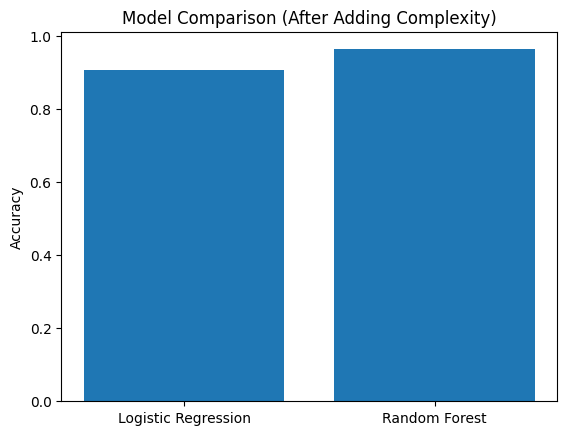

In [26]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Random Forest"]
scores = [lr_acc, rf_acc]

plt.figure()
plt.bar(models, scores)
plt.title("Model Comparison (After Adding Complexity)")
plt.ylabel("Accuracy")
plt.show()

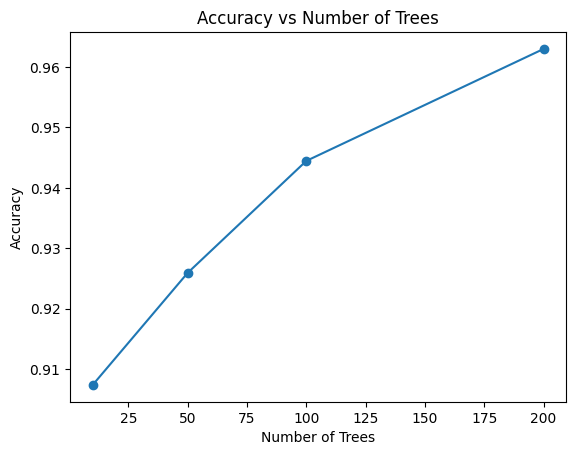

In [27]:
n_values = [10, 50, 100, 200]
scores = []

for n in n_values:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    scores.append(rf.score(X_test, y_test))

plt.figure()
plt.plot(n_values, scores, marker='o')
plt.title("Accuracy vs Number of Trees")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.show()

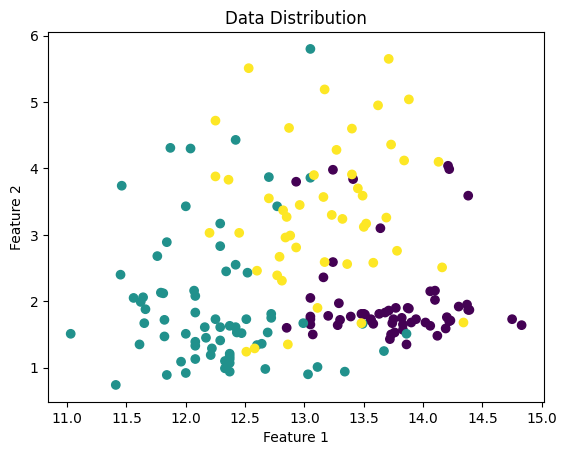

In [28]:
plt.figure()
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Data Distribution")
plt.show()

In [34]:
import pandas as pd

report = classification_report(y_test, rf_pred, output_dict=True)
df = pd.DataFrame(report).transpose()

print(df)

              precision    recall  f1-score    support
0              1.000000  0.947368  0.972973  19.000000
1              0.913043  1.000000  0.954545  21.000000
2              1.000000  0.928571  0.962963  14.000000
accuracy       0.962963  0.962963  0.962963   0.962963
macro avg      0.971014  0.958647  0.963494  54.000000
weighted avg   0.966184  0.962963  0.963212  54.000000


In [35]:
best_rf = grid.best_estimator_

In [36]:
best_pred = best_rf.predict(X_test)

In [37]:
from sklearn.metrics import classification_report

print("🔹 Logistic Regression:\n")
print(classification_report(y_test, lr_pred))

print("\n🔹 Random Forest (Base):\n")
print(classification_report(y_test, rf_pred))

print("\n🔹 Random Forest (Tuned - GridSearchCV):\n")
print(classification_report(y_test, best_pred))

🔹 Logistic Regression:

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        19
           1       0.86      0.90      0.88        21
           2       0.92      0.86      0.89        14

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.91        54
weighted avg       0.91      0.91      0.91        54


🔹 Random Forest (Base):

              precision    recall  f1-score   support

           0       1.00      0.95      0.97        19
           1       0.91      1.00      0.95        21
           2       1.00      0.93      0.96        14

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.97      0.96      0.96        54


🔹 Random Forest (Tuned - GridSearchCV):

              precision    recall  f1-score   support

           0       0.94      0.89      0.92        19
           1       0.88      1.00    